# Loan Default Prediction v2 – Improved Features & Models
**Target: ROC-AUC > 0.80**

In [2]:
import pandas as pd, numpy as np, json, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
import lightgbm as lgb
try:
    import xgboost as xgb; HAS_XGB = True
except: HAS_XGB = False
print('Libraries ready. XGBoost:', HAS_XGB)

Libraries ready. XGBoost: True


## 1. Load Data

In [3]:
BASE = r'd:/monsoon credit/senior_ds_test/data'
train_flag = pd.read_csv(f'{BASE}/train/train_flag.csv')
test_flag  = pd.read_csv(f'{BASE}/test/test_flag.csv')
print('Train:', train_flag.shape, '| Default rate:', round(train_flag['TARGET'].mean()*100,2), '%')
with open(f'{BASE}/train/accounts_data_train.json') as f: acc_train = json.load(f)
with open(f'{BASE}/train/enquiry_data_train.json')  as f: enq_train = json.load(f)
with open(f'{BASE}/test/accounts_data_test.json')   as f: acc_test  = json.load(f)
with open(f'{BASE}/test/enquiry_data_test.json')    as f: enq_test  = json.load(f)
print('All data loaded.')

Train: (261383, 3) | Default rate: 8.06 %
All data loaded.


## 2. Feature Engineering

**Key improvements over v1:**
- 30/60/90+ DPD severity buckets
- Last 3/6/12 month DPD recency
- Current open-loan delinquency
- Loans opened in last 12/24 months
- Enquiry velocity (1m/3m/6m/12m)
- Worsening trend (recent vs historical DPD)
- Interaction features (enquiry-to-debt ratio etc.)
- Missing = -1 (distinct from 0 = no delinquency)

In [4]:
REF = datetime(2021, 1, 1)

def parse_hist(s):
    if not isinstance(s, str) or not s: return []
    vals = []
    for i in range(0, len(s)-2, 3):
        try: vals.append(int(s[i:i+3]))
        except: pass
    return vals if vals else [int(c) for c in s if c.isdigit()]

def hist_feats(s):
    vals = parse_hist(s)
    Z = {'max_dpd':0,'avg_dpd':0,'last_dpd':0,'l3max':0,'l6max':0,'l12max':0,
         'ever30':0,'ever60':0,'ever90':0,'n30':0,'n60':0,'n90':0,
         'bad_rate':0,'worsening':0,'n_months':0}
    if not vals: return Z
    r = vals[::-1]
    def top(n): return max(r[:n]) if len(r)>=n else (max(r) if r else 0)
    trend = (np.mean(r[:3])-np.mean(r[3:6])) if len(r)>=6 else 0
    return {
        'max_dpd': max(vals), 'avg_dpd': float(np.mean(vals)),
        'last_dpd': r[0], 'l3max': top(3), 'l6max': top(6), 'l12max': top(12),
        'ever30': int(max(vals)>=30), 'ever60': int(max(vals)>=60), 'ever90': int(max(vals)>=90),
        'n30': sum(1 for v in vals if v>=30),
        'n60': sum(1 for v in vals if v>=60),
        'n90': sum(1 for v in vals if v>=90),
        'bad_rate': sum(1 for v in vals if v>0)/len(vals),
        'worsening': float(trend), 'n_months': len(vals),
    }

def sf(v, d=0):
    if v is None: return d
    if isinstance(v, float) and np.isnan(v): return d
    return v

print(hist_feats('000000000000000014044000000000000000000000000000'))

{'max_dpd': 44, 'avg_dpd': 3.625, 'last_dpd': 0, 'l3max': 0, 'l6max': 0, 'l12max': 44, 'ever30': 1, 'ever60': 0, 'ever90': 0, 'n30': 1, 'n60': 0, 'n90': 0, 'bad_rate': 0.125, 'worsening': 0.0, 'n_months': 16}


In [5]:
def build_acc(raw):
    rows = []
    for group in raw:
        if not group: continue
        uid = group[0]['uid']
        n   = len(group)
        hf  = [hist_feats(r.get('payment_hist_string','')) for r in group]
        is_open = [sf(r.get('closed_date')) == 0 or
                   (isinstance(r.get('closed_date'), float) and np.isnan(r.get('closed_date',0)))
                   for r in group]
        amts  = [sf(r.get('loan_amount',0)) for r in group]
        ovdus = [sf(r.get('amount_overdue',0)) for r in group]
        oa    = [a for a,o in zip(amts,is_open) if o]
        oo    = [v for v,o in zip(ovdus,is_open) if o]
        oh    = [h for h,o in zip(hf,is_open) if o]
        ages, r12, r24 = [], 0, 0
        for r in group:
            try:
                age = (REF - datetime.strptime(r['open_date'],'%Y-%m-%d')).days/30
                ages.append(age)
                r12 += age<=12; r24 += age<=24
            except: pass
        ct = [r.get('credit_type','').lower() for r in group]
        def ag(k,fn=max): return fn([h[k] for h in hf]) if hf else 0
        def sm(k): return sum(h[k] for h in hf)
        def mn(k): return float(np.mean([h[k] for h in hf])) if hf else 0
        rows.append({
            'uid':uid,
            'acc_n':n, 'acc_n_open':sum(is_open), 'acc_n_closed':n-sum(is_open),
            'acc_open_ratio':sum(is_open)/n,
            'acc_recent12m':r12, 'acc_recent24m':r24,
            'acc_total_loan':sum(amts), 'acc_max_loan':max(amts) if amts else 0,
            'acc_total_overdue':sum(ovdus), 'acc_overdue_ratio':sum(ovdus)/(sum(amts)+1),
            'acc_open_debt':sum(oa), 'acc_open_overdue':sum(oo),
            'acc_open_ov_ratio':sum(oo)/(sum(oa)+1),
            'acc_max_dpd':ag('max_dpd'), 'acc_avg_dpd':mn('avg_dpd'),
            'acc_last_dpd':ag('last_dpd'),
            'acc_l3max':ag('l3max'), 'acc_l6max':ag('l6max'), 'acc_l12max':ag('l12max'),
            'acc_ever30':int(ag('ever30')>0), 'acc_ever60':int(ag('ever60')>0),
            'acc_ever90':int(ag('ever90')>0),
            'acc_n30':sm('n30'), 'acc_n60':sm('n60'), 'acc_n90':sm('n90'),
            'acc_n_bad_loans':sum(1 for h in hf if h['ever30']),
            'acc_bad_loan_rate':sum(1 for h in hf if h['ever30'])/n,
            'acc_total_months':sm('n_months'), 'acc_avg_bad_rate':mn('bad_rate'),
            'acc_worsening':mn('worsening'),
            'acc_cur_dpd':max(h['last_dpd'] for h in oh) if oh else 0,
            'acc_n_open_bad':sum(h['ever30'] for h in oh),
            'acc_cur_delinquent':int(max((h['last_dpd'] for h in oh), default=0)>0),
            'acc_avg_age':float(np.mean(ages)) if ages else 0,
            'acc_oldest':max(ages) if ages else 0,
            'acc_n_cc':sum(1 for c in ct if 'credit card' in c),
            'acc_n_consumer':sum(1 for c in ct if 'consumer' in c),
            'acc_n_mortgage':sum(1 for c in ct if 'mortgage' in c or 'real estate' in c),
            'acc_n_auto':sum(1 for c in ct if 'car' in c or 'auto' in c),
        })
    return pd.DataFrame(rows)

print('Building acc train...')
acc_tr = build_acc(acc_train)
print('Building acc test...')
acc_te = build_acc(acc_test)
print('acc_tr:', acc_tr.shape)

Building acc train...
Building acc test...
acc_tr: (223918, 40)


In [6]:
def build_enq(raw):
    rows = []
    for group in raw:
        if not group: continue
        uid = group[0]['uid']
        n   = len(group)
        amts = [r.get('enquiry_amt',0) or 0 for r in group]
        dates = []
        for r in group:
            try: dates.append(datetime.strptime(r['enquiry_date'],'%Y-%m-%d'))
            except: pass
        ld = (REF-max(dates)).days if dates else 9999
        fd = (REF-min(dates)).days if dates else 9999
        sp = (max(dates)-min(dates)).days if len(dates)>1 else 0
        def rc(d): return sum(1 for x in dates if (REF-x).days<=d)
        types = [r.get('enquiry_type','').lower() for r in group]
        rows.append({
            'uid':uid,
            'enq_n':n, 'enq_total':sum(amts), 'enq_avg':sum(amts)/n,
            'enq_max':max(amts) if amts else 0,
            'enq_last_days':ld, 'enq_first_days':fd, 'enq_span':sp,
            'enq_1m':rc(30), 'enq_3m':rc(90), 'enq_6m':rc(180), 'enq_12m':rc(365),
            'enq_n_cash':sum(1 for t in types if 'cash' in t),
            'enq_n_interbank':sum(1 for t in types if 'interbank' in t),
            'enq_n_car':sum(1 for t in types if 'car' in t),
            'enq_velocity':n/max(sp/365,0.1),
        })
    return pd.DataFrame(rows)

print('Building enq train...')
enq_tr = build_enq(enq_train)
print('Building enq test...')
enq_te = build_enq(enq_test)
print('enq_tr:', enq_tr.shape)

Building enq train...
Building enq test...
enq_tr: (261383, 16)


In [7]:
train = train_flag.merge(acc_tr, on='uid', how='left').merge(enq_tr, on='uid', how='left')
test  = test_flag.merge(acc_te,  on='uid', how='left').merge(enq_te,  on='uid', how='left')

train['is_revolving'] = (train['NAME_CONTRACT_TYPE']=='Revolving loans').astype(int)
test['is_revolving']  = (test['NAME_CONTRACT_TYPE']=='Revolving loans').astype(int)
train['no_acc_hist']  = train['acc_n'].isna().astype(int)
test['no_acc_hist']   = test['acc_n'].isna().astype(int)

# Interaction features
for df in [train, test]:
    df['enq_to_debt']      = df['enq_total'] / (df['acc_open_debt'] + 1)
    df['enq6m_per_loan']   = df['enq_6m']    / (df['acc_n'] + 1)
    df['overdue_per_loan'] = df['acc_total_overdue'] / (df['acc_n'] + 1)
    df['dpd_x_open']       = df['acc_max_dpd'] * df['acc_n_open']
    df['recent_bad_debt']  = df['acc_l6max'] * df['acc_open_debt']

FEAT = [c for c in train.columns if c not in ['uid','NAME_CONTRACT_TYPE','TARGET']]
# Fill -1 for missing = thin file (distinct from 0 = clean record)
train[FEAT] = train[FEAT].fillna(-1)
test[FEAT]  = test[FEAT].fillna(-1)

X      = train[FEAT].values.astype('float32')
y      = train['TARGET'].values
X_test = test[FEAT].values.astype('float32')
print('Features:', len(FEAT), '| X shape:', X.shape)

Features: 61 | X shape: (261383, 61)


In [8]:
corr = train[FEAT+['TARGET']].corr()['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print('Top 20 correlations with TARGET:')
print(corr.head(20).round(4))

Top 20 correlations with TARGET:
acc_avg_age          0.0833
acc_oldest           0.0724
enq_first_days       0.0717
acc_recent12m        0.0569
acc_recent24m        0.0479
enq_span             0.0477
enq_velocity         0.0395
acc_n_mortgage       0.0375
acc_n_closed         0.0374
acc_n_open           0.0354
enq6m_per_loan       0.0335
enq_3m               0.0330
enq_last_days        0.0323
enq_6m               0.0319
no_acc_hist          0.0314
is_revolving         0.0310
acc_overdue_ratio    0.0309
acc_bad_loan_rate    0.0304
acc_avg_bad_rate     0.0301
acc_ever90           0.0297
Name: TARGET, dtype: float64


## 3. Baseline – Logistic Regression

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr  = Pipeline([('s',StandardScaler()),
                ('m',LogisticRegression(C=0.05, max_iter=500, class_weight='balanced'))])
lr_cv = cross_val_score(lr, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
print(f'Logistic Regression CV AUC: {lr_cv.mean():.4f} +/- {lr_cv.std():.4f}')

Logistic Regression CV AUC: 0.6732 +/- 0.0014


## 4. LightGBM – Improved Hyperparameters

In [10]:
pos_w = (y==0).sum()/(y==1).sum()
lgb_p = {
    'objective':'binary','metric':'auc',
    'learning_rate':0.02,'num_leaves':127,'max_depth':-1,
    'min_child_samples':30,'feature_fraction':0.7,
    'bagging_fraction':0.7,'bagging_freq':5,
    'reg_alpha':0.05,'reg_lambda':0.1,
    'scale_pos_weight':pos_w,'random_state':42,'verbose':-1,
}
oof_lgb = np.zeros(len(X)); pred_lgb = np.zeros(len(X_test))
lgb_models = []
for fold,(ti,vi) in enumerate(skf.split(X,y)):
    dtr = lgb.Dataset(X[ti],y[ti],feature_name=FEAT)
    dva = lgb.Dataset(X[vi],y[vi],feature_name=FEAT)
    m = lgb.train(lgb_p, dtr, num_boost_round=3000, valid_sets=[dva],
        callbacks=[lgb.early_stopping(150,verbose=False),lgb.log_evaluation(500)])
    oof_lgb[vi] = m.predict(X[vi])
    pred_lgb   += m.predict(X_test)/5
    lgb_models.append(m)
    print(f'  Fold {fold+1} AUC: {roc_auc_score(y[vi],oof_lgb[vi]):.4f} iter={m.best_iteration}')
lgb_auc = roc_auc_score(y, oof_lgb)
print(f'LightGBM OOF AUC: {lgb_auc:.4f}')

  Fold 1 AUC: 0.6732 iter=279
  Fold 2 AUC: 0.6716 iter=240
  Fold 3 AUC: 0.6715 iter=200
  Fold 4 AUC: 0.6718 iter=229
  Fold 5 AUC: 0.6668 iter=183
LightGBM OOF AUC: 0.6710


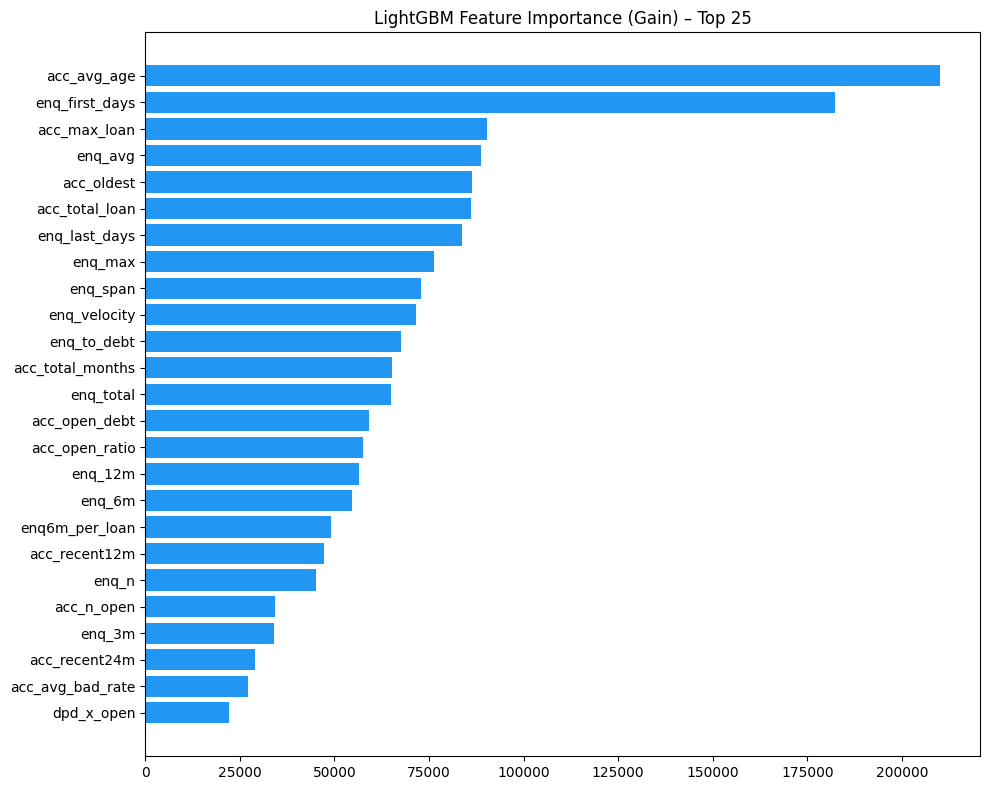

In [11]:
imp = pd.DataFrame({'f':FEAT,'g':np.mean([m.feature_importance('gain') for m in lgb_models],0)})
imp = imp.sort_values('g').tail(25)
plt.figure(figsize=(10,8))
plt.barh(imp['f'], imp['g'], color='#2196F3')
plt.title('LightGBM Feature Importance (Gain) – Top 25')
plt.tight_layout(); plt.show()

## 5. XGBoost

In [12]:
if HAS_XGB:
    xp = dict(objective='binary:logistic',eval_metric='auc',
              learning_rate=0.02,max_depth=6,n_estimators=3000,
              subsample=0.7,colsample_bytree=0.7,min_child_weight=30,
              scale_pos_weight=pos_w,random_state=42,
              tree_method='hist',verbosity=0)
    oof_xgb = np.zeros(len(X)); pred_xgb = np.zeros(len(X_test))
    for fold,(ti,vi) in enumerate(skf.split(X,y)):
        m = xgb.XGBClassifier(**xp, early_stopping_rounds=150, n_jobs=-1)
        m.fit(X[ti],y[ti],eval_set=[(X[vi],y[vi])],verbose=500)
        oof_xgb[vi] = m.predict_proba(X[vi])[:,1]
        pred_xgb   += m.predict_proba(X_test)[:,1]/5
        print(f'  Fold {fold+1} AUC: {roc_auc_score(y[vi],oof_xgb[vi]):.4f}')
    xgb_auc = roc_auc_score(y, oof_xgb)
    print(f'XGBoost OOF AUC: {xgb_auc:.4f}')
else:
    print('XGBoost not installed – pip install xgboost')
    oof_xgb=oof_lgb.copy(); pred_xgb=pred_lgb.copy(); xgb_auc=lgb_auc

[0]	validation_0-auc:0.63143
[500]	validation_0-auc:0.67603
[612]	validation_0-auc:0.67544
  Fold 1 AUC: 0.6763
[0]	validation_0-auc:0.63310
[500]	validation_0-auc:0.67432
[608]	validation_0-auc:0.67447
  Fold 2 AUC: 0.6746
[0]	validation_0-auc:0.62328
[500]	validation_0-auc:0.67536
[542]	validation_0-auc:0.67517
  Fold 3 AUC: 0.6758
[0]	validation_0-auc:0.62613
[500]	validation_0-auc:0.67514
[701]	validation_0-auc:0.67473
  Fold 4 AUC: 0.6753
[0]	validation_0-auc:0.62489
[500]	validation_0-auc:0.67054
[581]	validation_0-auc:0.67049
  Fold 5 AUC: 0.6708
XGBoost OOF AUC: 0.6745


## 6. Ensemble

  Logistic Regression AUC  : 0.6732
  LightGBM OOF AUC         : 0.6710
  XGBoost OOF AUC          : 0.6745
  Ensemble AUC (w=0.20)   : 0.6745


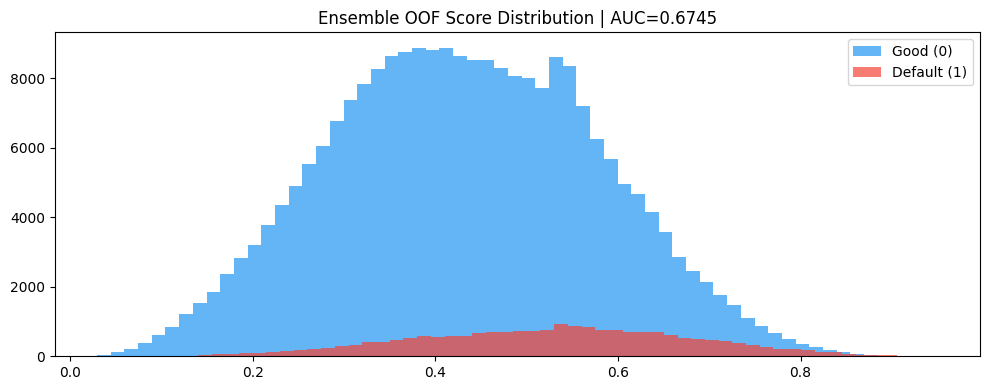

In [13]:
best_w, best_a = 0.5, 0
for w in np.arange(0.2, 0.9, 0.05):
    a = roc_auc_score(y, w*oof_lgb+(1-w)*oof_xgb)
    if a>best_a: best_a,best_w=a,w

oof_blend  = best_w*oof_lgb  + (1-best_w)*oof_xgb
pred_blend = best_w*pred_lgb + (1-best_w)*pred_xgb
blend_auc  = roc_auc_score(y, oof_blend)

print('='*50)
print(f'  Logistic Regression AUC  : {lr_cv.mean():.4f}')
print(f'  LightGBM OOF AUC         : {lgb_auc:.4f}')
print(f'  XGBoost OOF AUC          : {xgb_auc:.4f}')
print(f'  Ensemble AUC (w={best_w:.2f})   : {blend_auc:.4f}')
print('='*50)

fig,ax = plt.subplots(figsize=(10,4))
ax.hist(oof_blend[y==0],bins=60,alpha=0.7,color='#2196F3',label='Good (0)')
ax.hist(oof_blend[y==1],bins=60,alpha=0.7,color='#F44336',label='Default (1)')
ax.set_title(f'Ensemble OOF Score Distribution | AUC={blend_auc:.4f}')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Final Submission

In [14]:
sub = pd.DataFrame({'uid':test['uid'],'pred':pred_blend})
out = r'd:/monsoon credit/senior_ds_test/data/final_submission/final_submission_tejasv_gupta.csv'
sub.to_csv(out, index=False)
print('Saved:', out)
print(sub['pred'].describe().round(4))
sub.head()

Saved: d:/monsoon credit/senior_ds_test/data/final_submission/final_submission_tejasv_gupta.csv
count    46127.0000
mean         0.4394
std          0.1472
min          0.0281
25%          0.3316
50%          0.4364
75%          0.5453
max          0.9249
Name: pred, dtype: float64


,uid,pred
0,CMO22835242,0.306271
1,MRJ34316727,0.649892
2,UAV00534378,0.530806
3,IPQ08190402,0.425907
4,NQN84331006,0.460007
